# Data Preprocessing

In [1]:
#install required libraries
! pip install pandas numpy matplotlib seaborn jupyter scikit-learn


In [2]:
#import required libraries
import pandas as pd               # For data manipulation
import numpy as np                # For numerical operations
import matplotlib.pyplot as plt   # For plotting charts
import seaborn as sns             # For advanced visualizations
from sklearn.preprocessing import StandardScaler  #For scaling
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('retail_data.csv')

# Initial EDA

In [4]:
#get the numerical summary of the data set
df.describe()

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,3.016770e+05,301702.000000,3.016480e+05,301670.000000,301837.000000,301660.000000,301649.000000,301653.000000,301660.000000,301826.000000
mean,5.495823e+06,55006.553934,5.501464e+09,50298.951019,35.481326,2023.165113,5.359729,255.163659,1367.651156,3.162670
std,2.595565e+06,26005.675200,2.596017e+09,28972.807134,15.021933,0.371283,2.868575,141.389640,1128.998515,1.320827
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247930e+06,32469.250000,3.255061e+09,25425.000000,22.000000,2023.000000,3.000000,132.890764,438.724278,2.000000
50%,5.499657e+06,55012.000000,5.505812e+09,50602.500000,32.000000,2023.000000,5.000000,255.470969,1041.117547,3.000000
75%,7.739509e+06,77511.000000,7.749860e+09,75252.000000,46.000000,2023.000000,8.000000,377.672606,2029.999853,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024.000000,10.000000,499.997911,4999.625796,5.000000


In [5]:
#check the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

In [6]:
#check the missing values per column as percentage
df.isnull().sum().sort_values(ascending=False)
(df.isnull().mean() * 100).sort_values(ascending=False)


Name                0.126486
Phone               0.119864
Total_Purchases     0.119532
Date                0.118870
Amount              0.118208
Year                0.115890
Time                0.115890
Total_Amount        0.115890
Email               0.114897
Zipcode             0.112579
Shipping_Method     0.111586
Transaction_ID      0.110261
Gender              0.104963
Address             0.104301
Customer_ID         0.101983
Payment_Method      0.098341
Income              0.096023
Product_Category    0.093706
State               0.093043
Product_Brand       0.093043
Month               0.090394
Country             0.089732
City                0.082116
Order_Status        0.077812
Customer_Segment    0.071190
Ratings             0.060925
Feedback            0.060925
Age                 0.057283
Product_Type        0.000000
products            0.000000
dtype: float64

## Dealing with the missing values

In [7]:
# List of columns
ncol = ['Name', 'Email', 'Shipping_Method', 'Gender', 'Address', 'Payment_Method', 
        'Product_Category', 'State', 'Product_Brand', 'Country', 'City', 
        'Order_Status', 'Customer_Segment', 'Feedback']

# Fill nulls in those columns with "Not Provided" 
# These columns are categorical hence could not replace with the mean, median or mode
df[ncol] = df[ncol].fillna('Not Provided')

#Fill the nulls with Median
mcol = ['Total_Purchases', 'Amount', 'Income', 'Total_Amount']
df[mcol] = df[mcol].fillna(df['Age'].median())

##fill the nulls with Mean
col = ['Ratings', 'Age']
df[col] = df[col].fillna(df[col].mean())




In [8]:
#change the data type of columns
cols = ['Customer_ID', 'Transaction_ID', 'Phone', 'Zipcode','Year']

df[cols] = df[cols].astype(str)
df['Age'] = df['Age'].astype(int)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    302010 non-null  object 
 1   Customer_ID       302010 non-null  object 
 2   Name              302010 non-null  object 
 3   Email             302010 non-null  object 
 4   Phone             302010 non-null  object 
 5   Address           302010 non-null  object 
 6   City              302010 non-null  object 
 7   State             302010 non-null  object 
 8   Zipcode           302010 non-null  object 
 9   Country           302010 non-null  object 
 10  Age               302010 non-null  int64  
 11  Gender            302010 non-null  object 
 12  Income            302010 non-null  object 
 13  Customer_Segment  302010 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              302010 non-null  object 
 16  Month             30

In [10]:
#check the duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')


Duplicate rows: 4


In [11]:
#remove the duplicated rows
df = df.drop_duplicates()


In [12]:
#get the cleaned data set
df.to_csv('cleaned_retail_data.csv', index=False)


## Outlier Detection

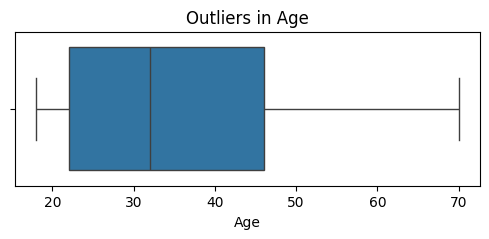

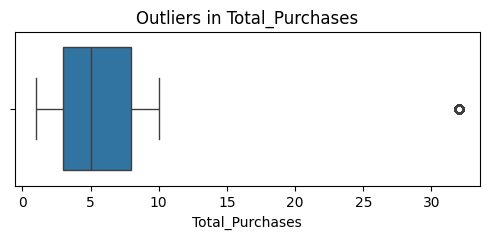

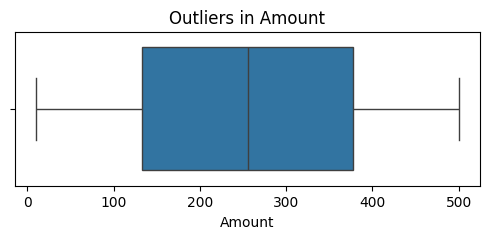

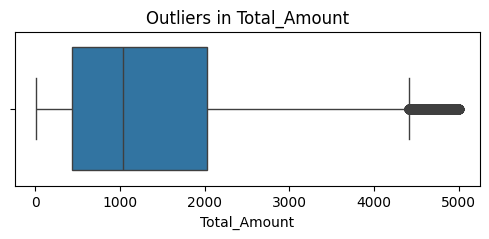

In [13]:
numeric_cols = ['Age', 'Total_Purchases', 'Amount', 'Total_Amount']

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()


The boxplot shows that Total_Purchases and Total_Amount has outliers. Hence the outliers will be removed

In [14]:
#applied the quantile based outlier mapping for 1% values.
df = df[df['Total_Amount'] < df['Total_Amount'].quantile(0.99)]
df = df[df['Total_Purchases'] < df['Total_Purchases'].quantile(0.99)]


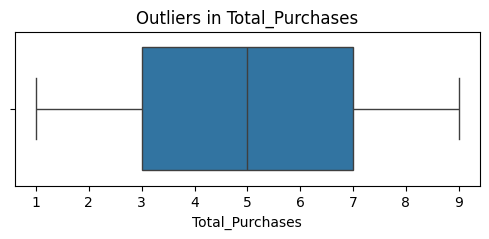

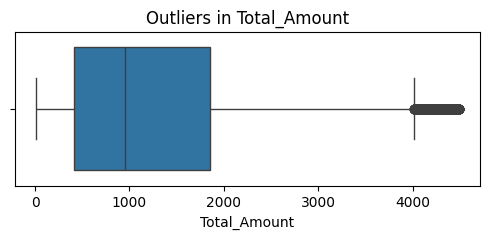

In [15]:
#The boxplots after removed the outliers.

numeric_cols = ['Total_Purchases', 'Total_Amount']

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()


# Feature Engineering

In [16]:
#convert Date column into date time type
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#extract the date and month seperately
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

#fill the Year and Month column by date column
df['Year'] = df['Year'].fillna(df['Year'].mode()[0])
df['Month'] = df['Month'].fillna(df['Month'].mode()[0])

#fill the Time Column
df['Time'] = df['Time'].fillna('00:00:00')

In [17]:
#Create new columns (Features)

# Average order value
df['Avg_Order_Value'] = df['Total_Amount'] / df['Total_Purchases']

# Handle divide-by-zero or infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df['Avg_Order_Value'] = df['Avg_Order_Value'].fillna(df['Avg_Order_Value'].median())

#spending intensity
df['Spend_per_Purchase'] = df['Total_Amount'] / (df['Total_Purchases'] + 1)


#Create the ML Model

This model is developed to analyze the customer behaviour based using customer segmentation by K-means clustering.
The model is developed based on unsupervised learning technique.

In [18]:
features = [
    'Age',
    'Total_Purchases',
    'Total_Amount',
    'Avg_Order_Value',
    'Ratings'
]

X = df[features]


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


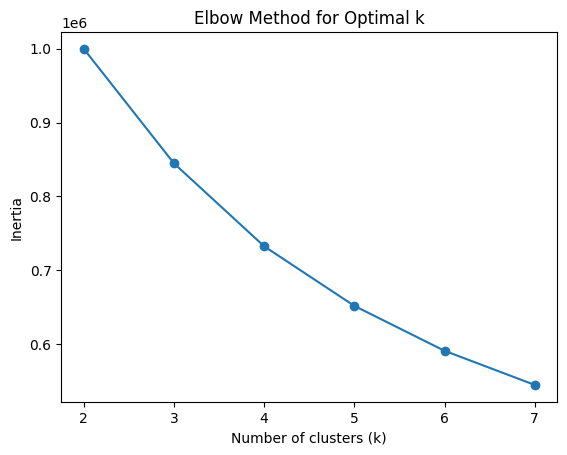

In [20]:
#Elbow point method to find optimal number of clusters

from sklearn.cluster import KMeans

inertia = []
K = range(2, 8)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


In [21]:
#based on the results, 4 clusters has used to implement K-means clustering

kmeans = KMeans(n_clusters=4, random_state=42)
df['Customer_Cluster'] = kmeans.fit_predict(X_scaled)


In [22]:
#Evaluate the model

df.groupby('Customer_Cluster')[features].mean()

,Age,Total_Purchases,Total_Amount,Avg_Order_Value,Ratings
Customer_Cluster,,,,,
0,40.152461,6.508443,766.657229,115.308791,3.691724
1,35.844867,7.111551,2668.665802,381.000731,3.153806
2,27.254732,3.604430,720.973758,214.208717,1.694407
3,38.263583,2.418103,705.980779,285.326970,4.036290


In [23]:
#Add cluster lables to the data set

cluster_names = {
    0: 'Regular Customers',
    1: 'High-Value Loyal Customers',
    2: 'At-Risk Customers',
    3: 'Premium Occasional Buyers'
}

df['Cluster_Name'] = df['Customer_Cluster'].map(cluster_names)


c:\Users\Admin\anaconda3\envs\msv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


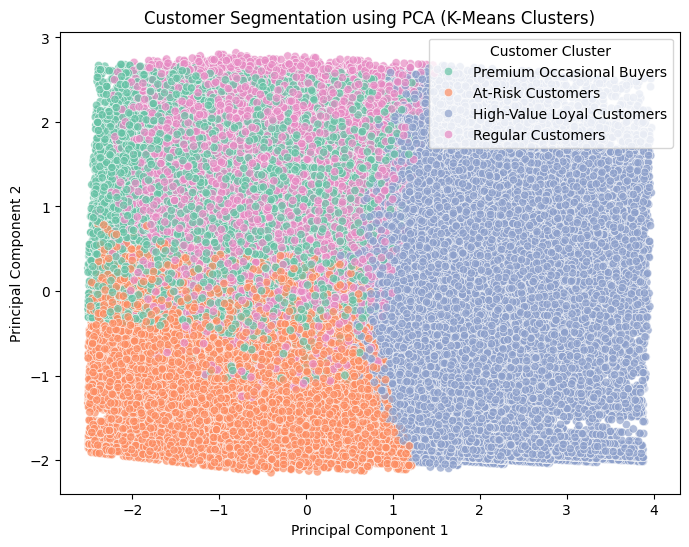

In [24]:
#Cluster Scatter Plot

#apply PCA for scaled feature
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#PCA data frame
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster_Name'] = df['Cluster_Name'].values

#cluster scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster_Name',
    palette='Set2',
    alpha=0.7
)

plt.title('Customer Segmentation using PCA (K-Means Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Cluster')
plt.show()


In [25]:
#get the final data set
df.to_csv("retail_data_with_clusters.csv", index=False)
